Prediction Model Performance Analysis (Jupyter Notebook Guide)

This guide gives you a complete analysis workflow for your betting prediction model using your predictions_tracker.xlsx file.

The goal is to help you understand:

Whether the model is improving
Which markets perform best
Daily/weekly profitability
Which leagues are strongest
Whether high-confidence predictions actually perform better
Whether odds and edge correlate with profit
Whether your bankroll management is working
How volatile your model is
Where are your biggest weaknesses

                                                                1. Install Required Libraries

Run this once:

In [1]:
pip install pandas matplotlib openpyxl numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


                                                        2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

                                                        3. Load Your Excel File

Use the exact filename/path below.

In [3]:
file_path = "predictions_tracker.xlsx"


# Read Predictions sheet
_df = pd.read_excel(file_path, sheet_name="Predictions")


# Make a working copy
_df = _df.copy()

                                                            4. Clean and Prepare Data

                                                            This is VERY important.

In [4]:
# Convert date column
_df['Date'] = pd.to_datetime(_df['Date'])


# Create day-only column
_df['Day'] = _df['Date'].dt.date


# Convert important columns to numeric
numeric_cols = [
    'Profit/Loss (RWF)',
    'Stake Placed (RWF)',
    'Odds Taken',
    'Edge%',
    'EV',
    'Kelly Stake (RWF)',
    'Home Win%',
    'Draw%',
    'Away Win%',
    'Over 2.5%',
    'Under 2.5%',
    'BTTS Yes%',
    'BTTS No%',
    'Bankroll After (RWF)',
    'Running ROI%'
]


for col in numeric_cols:
    _df[col] = pd.to_numeric(_df[col], errors='coerce')


# Keep only rows where a bet was actually placed
bets = _df[_df['Bet Placed? (Y/N)'] == 'Y'].copy()


# Remove rows without result
bets = bets[bets['Result (W/L/P)'].notna()].copy()

                                                                5. Quick Overview

                                                        This gives you a first look at your model.

In [5]:
print("Total Predictions:", len(_df))
print("Total Bets Placed:", len(bets))


print("\nTotal Profit/Loss:")
print(bets['Profit/Loss (RWF)'].sum())


print("\nAverage Profit Per Bet:")
print(bets['Profit/Loss (RWF)'].mean())


print("\nAverage Stake:")
print(bets['Stake Placed (RWF)'].mean())

Total Predictions: 153
Total Bets Placed: 126

Total Profit/Loss:
3126.15888

Average Profit Per Bet:
24.810784761904763

Average Stake:
940.8571428571429


                                                            6. Win Rate Analysis

In [6]:
wins = (bets['Result (W/L/P)'] == 'W').sum()
losses = (bets['Result (W/L/P)'] == 'L').sum()
pushes = (bets['Result (W/L/P)'] == 'P').sum()


win_rate = wins / (wins + losses) * 100


print(f"Wins: {wins}")
print(f"Losses: {losses}")
print(f"Pushes: {pushes}")
print(f"Win Rate: {win_rate:.2f}%")

Wins: 48
Losses: 78
Pushes: 0
Win Rate: 38.10%


                                                        7. Daily Profit/Loss Analysis

                                                    This is one of the most important sections.

                                                            It shows:

                                                    Which days were profitable
                                                    Whether the model is stabilizing
                                                    Whether profits are random or trending upward

In [7]:
daily_profit = bets.groupby('Day')['Profit/Loss (RWF)'].sum()


print(daily_profit)

Day
2026-04-21      52.26000
2026-04-22    8739.46000
2026-04-23   -1949.07000
2026-04-24   -5701.67000
2026-04-25   -1238.16000
2026-04-26     823.11000
2026-04-30    4144.00000
2026-05-02   -3222.84000
2026-05-03    1392.63000
2026-05-04    -581.39000
2026-05-05    -668.00000
2026-05-07    1335.82888
Name: Profit/Loss (RWF), dtype: float64


                                                                8. Daily Profit Chart

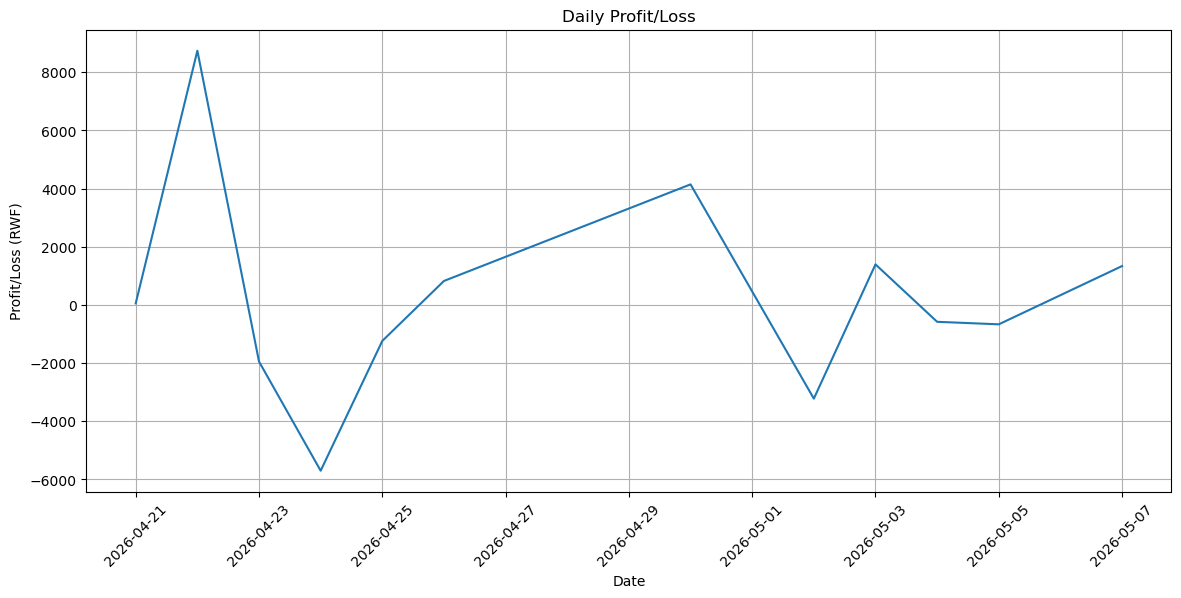

In [8]:
plt.figure(figsize=(14,6))


plt.plot(daily_profit.index, daily_profit.values)


plt.title('Daily Profit/Loss')
plt.xlabel('Date')
plt.ylabel('Profit/Loss (RWF)')
plt.xticks(rotation=45)


plt.grid(True)
plt.show()

What to look for:

Smooth upward curve = improving model
Huge spikes = high volatility
Flat periods = no edge
Consistent growth = real predictive power

                                                            9. Cumulative Profit Curve

This is your MOST IMPORTANT graph.

Professional bettors and quant traders watch this constantly.

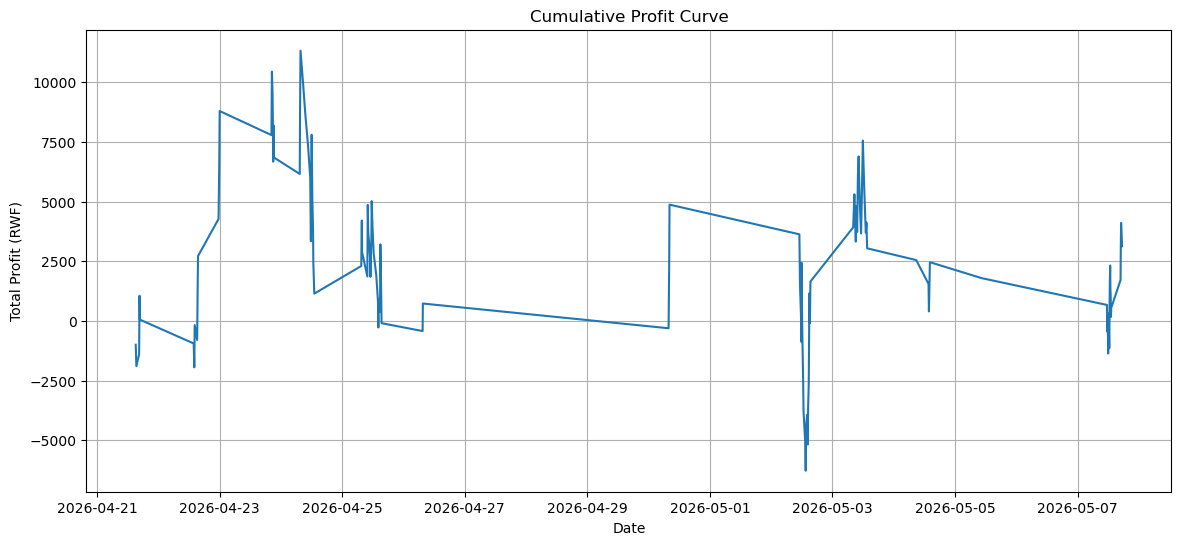

In [9]:
bets = bets.sort_values('Date')


bets['Cumulative Profit'] = bets['Profit/Loss (RWF)'].cumsum()


plt.figure(figsize=(14,6))


plt.plot(bets['Date'], bets['Cumulative Profit'])


plt.title('Cumulative Profit Curve')
plt.xlabel('Date')
plt.ylabel('Total Profit (RWF)')


plt.grid(True)
plt.show()

Interpretation:

Upward trend = profitable model
Sharp crashes = weak bankroll management
Sideways = randomness/no edge
Smooth upward slope = elite model behavior

                                                                10. ROI Analysis

In [10]:
total_profit = bets['Profit/Loss (RWF)'].sum()
total_staked = bets['Stake Placed (RWF)'].sum()


roi = (total_profit / total_staked) * 100


print(f"Total ROI: {roi:.2f}%")

Total ROI: 23.73%


General ROI Benchmarks:

Negative ROI = losing model
0% to 3% = weak edge
3% to 7% = decent betting model
7% to 15% = very strong
15%+ = exceptional

                                                                11. Profit by League

This helps identify where your model performs best.

In [11]:
league_profit = bets.groupby('League')['Profit/Loss (RWF)'].sum().sort_values()


print(league_profit)

League
L1   -12191.56000
BL    -2400.43512
PL     2120.08000
LL     5729.08400
SA     9868.99000
Name: Profit/Loss (RWF), dtype: float64


                                                            12. League Profit Chart

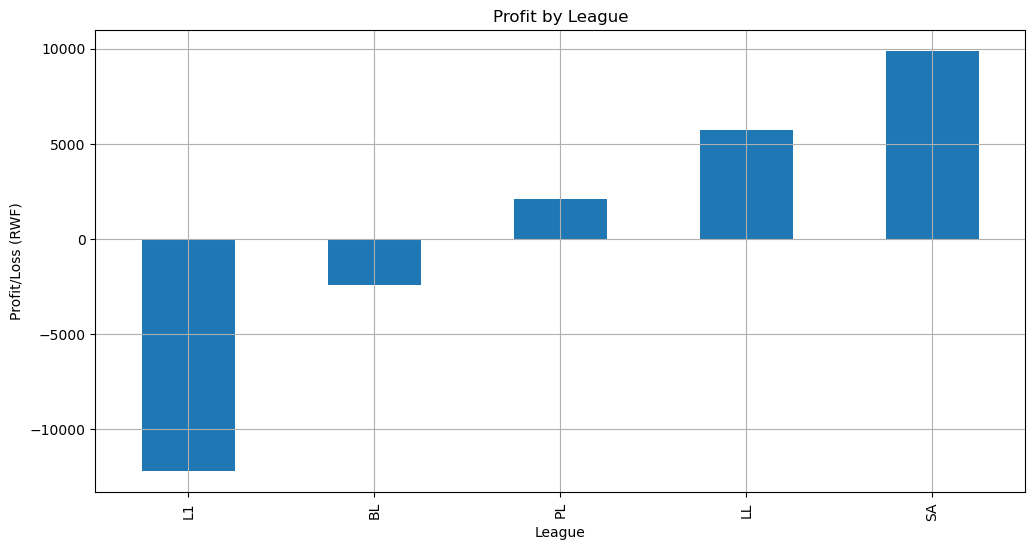

In [12]:
plt.figure(figsize=(12,6))


league_profit.plot(kind='bar')


plt.title('Profit by League')
plt.ylabel('Profit/Loss (RWF)')


plt.grid(True)
plt.show()

Insight:

Some leagues are much easier to model than others.

You may discover:

EPL is too efficient
Lower leagues have better edges
Some leagues consistently lose money

13. Best Market Analysis

In [13]:
market_profit = bets.groupby('Market Bet On')['Profit/Loss (RWF)'].sum().sort_values()


print(market_profit)

Market Bet On
home_un_1.5   -1906.000
away_un_0.5   -1331.000
away_win       -625.000
home_win        224.790
btts_no         501.260
home_un_2.5    1070.000
under_1.5      1212.000
cor_un_7.5     2084.720
under_2.5      2954.030
cor_ov_11.5    4543.846
Name: Profit/Loss (RWF), dtype: float64


14. Market Profit Chart

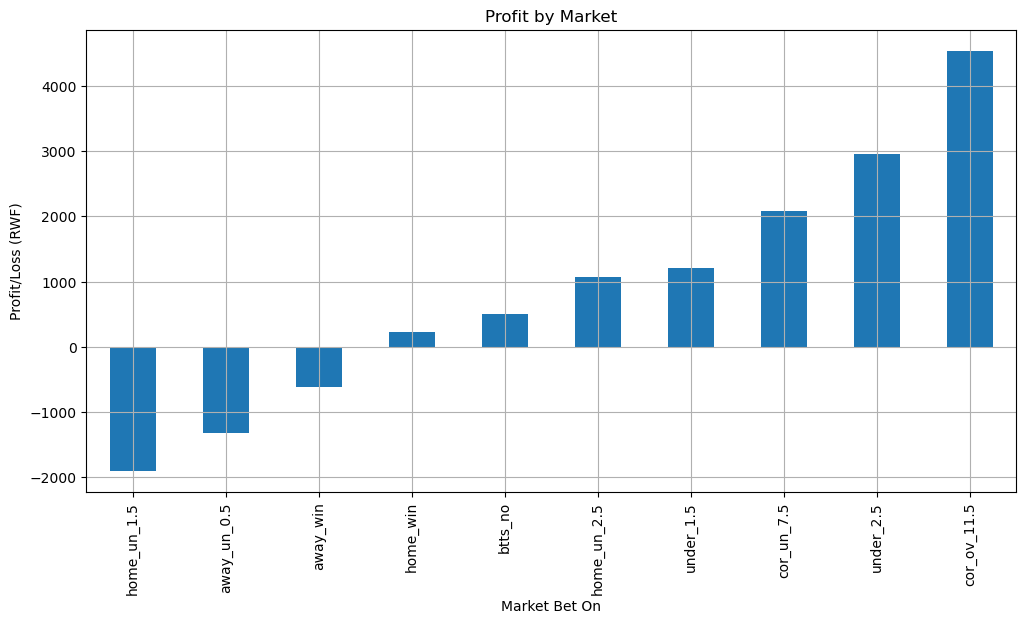

In [14]:
plt.figure(figsize=(12,6))


market_profit.plot(kind='bar')


plt.title('Profit by Market')
plt.ylabel('Profit/Loss (RWF)')


plt.grid(True)
plt.show()

This tells you:

Whether 1X2 is profitable
Whether BTTS works better
Whether Over/Under is your edge

15. Confidence vs Reality

This is CRITICAL.

You want to know:

"When my model says 70%, does it actually win around 70%?"

In [15]:
bets['Main Prediction Confidence'] = bets[['Home Win%', 'Draw%', 'Away Win%']].max(axis=1)


confidence_bins = pd.cut(
    bets['Main Prediction Confidence'],
    bins=[0,40,50,60,70,80,100]
)


confidence_analysis = bets.groupby(confidence_bins)['Profit/Loss (RWF)'].agg(['count','sum','mean'])


print(confidence_analysis)

                            count         sum         mean
Main Prediction Confidence                                
(0, 40]                        34 -4418.51400  -129.956294
(40, 50]                       40 -2540.92960   -63.523240
(50, 60]                       23  4708.44640   204.715061
(60, 70]                       18 -5655.10680  -314.172600
(70, 80]                        7  4676.53088   668.075840
(80, 100]                       4  6355.73200  1588.933000


C:\Users\Klevis SEMIGABO\AppData\Local\Temp\ipykernel_17964\4119386030.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  confidence_analysis = bets.groupby(confidence_bins)['Profit/Loss (RWF)'].agg(['count','sum','mean'])


16. Confidence Profit Chart

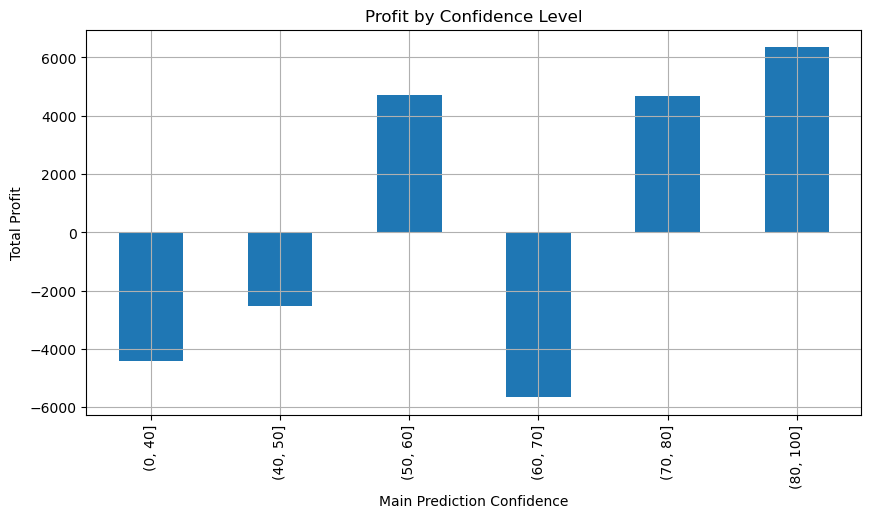

In [16]:
confidence_analysis['sum'].plot(kind='bar', figsize=(10,5))


plt.title('Profit by Confidence Level')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()

This is extremely important.

If high-confidence bets lose money:

Your probabilities are miscalibrated
Your model may be overconfident
You may be overfitting

17. Edge% Analysis

You track Edge%, which is great.

Now test if higher edge actually means more profit.

In [17]:
edge_bins = pd.cut(
    bets['Edge%'],
    bins=[-100,0,2,5,10,20,100]
)


edge_analysis = bets.groupby(edge_bins)['Profit/Loss (RWF)'].agg(['count','sum','mean'])


print(edge_analysis)

           count         sum        mean
Edge%                                   
(-100, 0]      0     0.00000         NaN
(0, 2]         0     0.00000         NaN
(2, 5]         5   708.92960  141.785920
(5, 10]       18   270.90528   15.050293
(10, 20]      58  8225.04800  141.811172
(20, 100]     45 -6078.72400 -135.082756


C:\Users\Klevis SEMIGABO\AppData\Local\Temp\ipykernel_17964\2197473421.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edge_analysis = bets.groupby(edge_bins)['Profit/Loss (RWF)'].agg(['count','sum','mean'])


18. Closing Line Value (CLV)

CLV is one of the strongest indicators of long-term betting skill.

If your odds beat the closing odds consistently, your model likely has real edge.

In [19]:
bets['CLV'] = bets['Closing Odds (fill after)'] - bets['Odds Taken']


print(bets['CLV'].describe())



count    120.000000
mean       0.019917
std        0.260737
min       -0.750000
25%       -0.092500
50%        0.000000
75%        0.057500
max        1.050000
Name: CLV, dtype: float64


19. CLV Distribution Chart

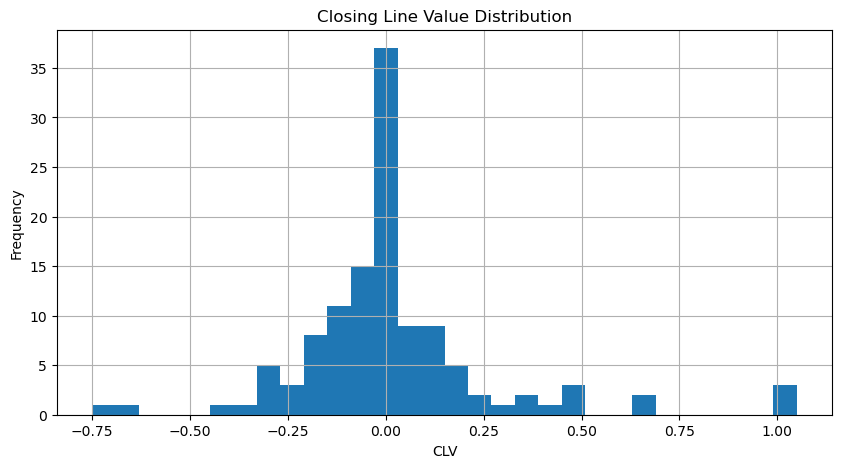

In [20]:
plt.figure(figsize=(10,5))


plt.hist(bets['CLV'].dropna(), bins=30)


plt.title('Closing Line Value Distribution')
plt.xlabel('CLV')
plt.ylabel('Frequency')


plt.grid(True)
plt.show()

21. Drawdown Analysis

This measures your worst losing streak.

Professional traders care about this heavily.

In [22]:
bets['Peak'] = bets['Cumulative Profit'].cummax()


bets['Drawdown'] = bets['Cumulative Profit'] - bets['Peak']


max_drawdown = bets['Drawdown'].min()


print(f"Maximum Drawdown: {max_drawdown:.2f} RWF")

Maximum Drawdown: -17598.40 RWF


22. Drawdown Chart

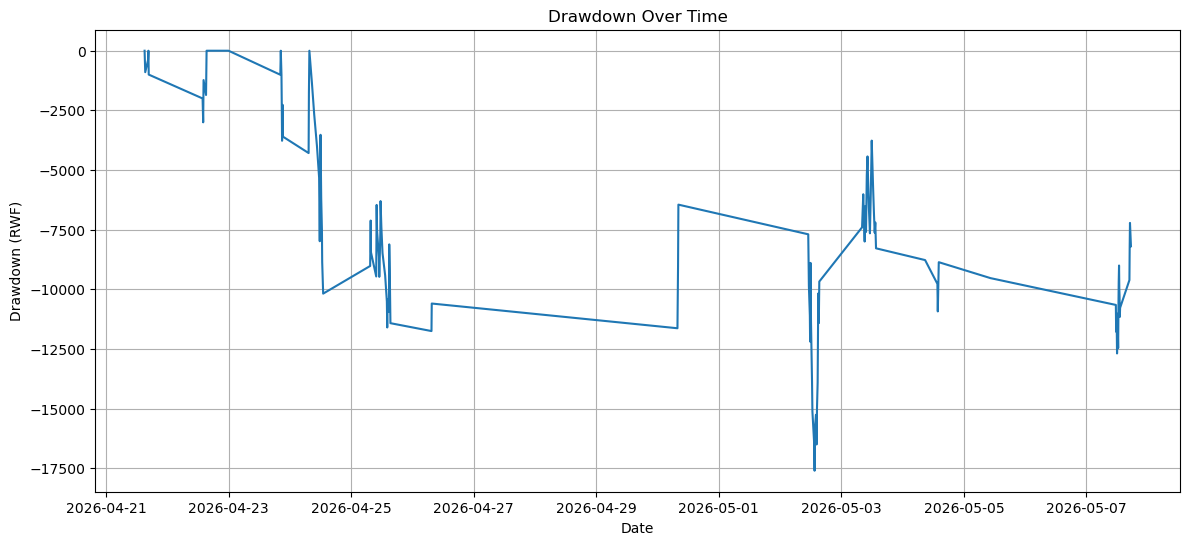

In [23]:
plt.figure(figsize=(14,6))


plt.plot(bets['Date'], bets['Drawdown'])


plt.title('Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (RWF)')


plt.grid(True)
plt.show()

Interpretation:

Small drawdowns = stable model
Massive drawdowns = risky model
Long recovery times = weak edge

23. Streak Analysis

In [24]:
bets['Win'] = bets['Result (W/L/P)'] == 'W'


streaks = []
current = 0
last = None


for result in bets['Win']:
    if result == last:
        current += 1
    else:
        current = 1
        last = result
    streaks.append(current)


bets['Streak'] = streaks


max_win_streak = bets.loc[bets['Win'], 'Streak'].max()
max_loss_streak = bets.loc[~bets['Win'], 'Streak'].max()


print("Max Win Streak:", max_win_streak)
print("Max Loss Streak:", max_loss_streak)

Max Win Streak: 5
Max Loss Streak: 7


24. Most Profitable Teams

In [25]:
home_profit = bets.groupby('Home Team')['Profit/Loss (RWF)'].sum()
away_profit = bets.groupby('Away Team')['Profit/Loss (RWF)'].sum()


team_profit = home_profit.add(away_profit, fill_value=0)


print(team_profit.sort_values(ascending=False).head(15))

Juventus           6122.48800
Burnley            5040.00000
Sevilla            4493.59960
AC Milan           4317.20000
Hellas Verona      4175.53000
Wolves             4065.01400
Rayo Vallecano     3726.35000
Tottenham          3376.85000
Sassuolo           3357.70000
Bayern Munich      3343.84288
Heidenheim         3296.60000
Parma              2927.87000
Genoa              2898.00000
Manchester City    2831.10800
Getafe             2819.40000
Name: Profit/Loss (RWF), dtype: float64


You may discover:

Some teams are consistently undervalued
Some teams fool your model repeatedly

25. Correlation Analysis

This tells you what variables matter most.

In [26]:
correlation_cols = [
    'Edge%',
    'EV',
    'Odds Taken',
    'Stake Placed (RWF)',
    'Profit/Loss (RWF)',
    'Home Win%',
    'Over 2.5%',
    'BTTS Yes%'
]


correlation_matrix = bets[correlation_cols].corr()


print(correlation_matrix)

                       Edge%        EV  Odds Taken  Stake Placed (RWF)  \
Edge%               1.000000  0.874210    0.429082            0.161863   
EV                  0.874210  1.000000    0.764235            0.152880   
Odds Taken          0.429082  0.764235    1.000000            0.104713   
Stake Placed (RWF)  0.161863  0.152880    0.104713            1.000000   
Profit/Loss (RWF)  -0.052619 -0.165455   -0.239164            0.290953   
Home Win%          -0.105683 -0.044962   -0.002323           -0.017848   
Over 2.5%          -0.382852 -0.303428   -0.152457           -0.406688   
BTTS Yes%          -0.404413 -0.296710   -0.080209           -0.510155   

                    Profit/Loss (RWF)  Home Win%  Over 2.5%  BTTS Yes%  
Edge%                       -0.052619  -0.105683  -0.382852  -0.404413  
EV                          -0.165455  -0.044962  -0.303428  -0.296710  
Odds Taken                  -0.239164  -0.002323  -0.152457  -0.080209  
Stake Placed (RWF)           0.290953  -0

26. Rolling 20-Bet Performance
This helps remove noise.

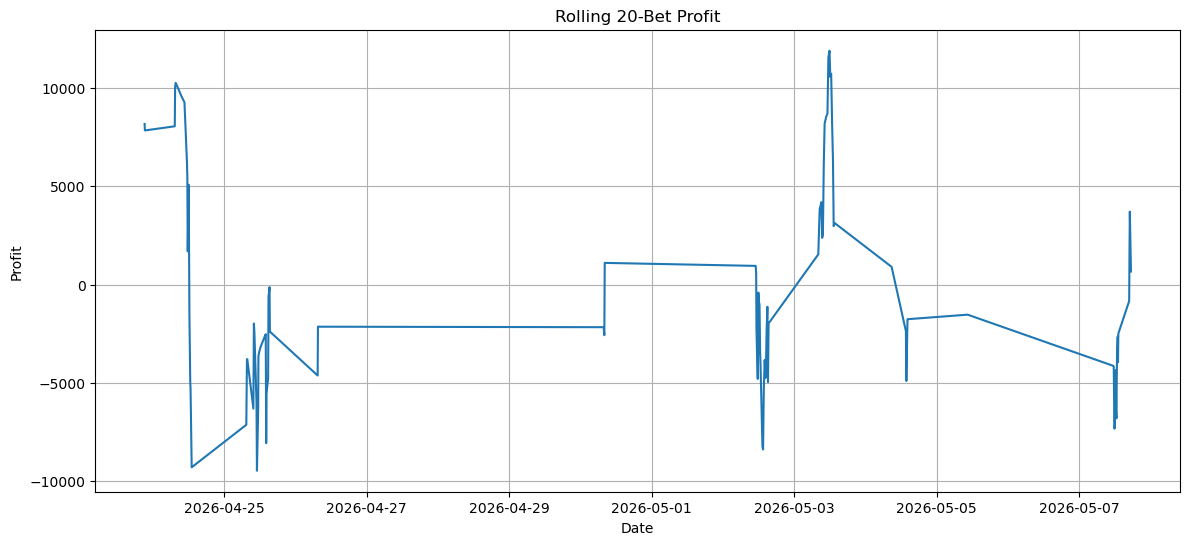

In [27]:
bets['Rolling Profit 20'] = bets['Profit/Loss (RWF)'].rolling(20).sum()


plt.figure(figsize=(14,6))


plt.plot(bets['Date'], bets['Rolling Profit 20'])


plt.title('Rolling 20-Bet Profit')
plt.xlabel('Date')
plt.ylabel('Profit')


plt.grid(True)
plt.show()

This is VERY useful because single bets are noisy.

Rolling windows show whether the model is actually improving.

27. Model Calibration Check
This is advanced but important.

In [28]:
bets['Predicted Win Probability'] = bets[['Home Win%', 'Draw%', 'Away Win%']].max(axis=1) / 100


bets['Actual Win'] = (bets['Result (W/L/P)'] == 'W').astype(int)


calibration = bets.groupby(pd.cut(bets['Predicted Win Probability'], bins=np.arange(0,1.1,0.1)))['Actual Win'].mean()


print(calibration)

Predicted Win Probability
(0.0, 0.1]         NaN
(0.1, 0.2]         NaN
(0.2, 0.3]         NaN
(0.3, 0.4]    0.323529
(0.4, 0.5]    0.350000
(0.5, 0.6]    0.434783
(0.6, 0.7]    0.277778
(0.7, 0.8]    0.571429
(0.8, 0.9]    1.000000
(0.9, 1.0]    1.000000
Name: Actual Win, dtype: float64


C:\Users\Klevis SEMIGABO\AppData\Local\Temp\ipykernel_17964\2082206061.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = bets.groupby(pd.cut(bets['Predicted Win Probability'], bins=np.arange(0,1.1,0.1)))['Actual Win'].mean()


If your model predicts:

80% probability
But actual wins are only 55%

then your model is overconfident.

28. Best Insights to Focus On

The most valuable metrics for your model are:

Cumulative profit curve
Rolling 20-bet profit
ROI
CLV
Drawdown
Confidence calibration
Profit by league
Profit by market

These separate:

Lucky short-term results from
Real predictive edge
29. Most Important Truth About Betting Models

Even good models experience:

Losing streaks
Drawdowns
Variance
Randomness